# Tanzania Food Demand System & Nutritional Adequacy Analysis
**Data:** Tanzania National Panel Survey (NPS/HBS) 2019–20  
**Recall period:** 7-day household food recall  
**Sample:** 1,110 households across Mainland Rural, Mainland Other Urban, Dar es Salaam, Zanzibar

---
### Outline
1. Setup & data loading  
2. Data cleaning and food group mapping  
3. Quantities, prices, and budget shares  
4. LA-AIDS demand system estimation  
5. Expenditure elasticities & Engel curves  
6. Nutrient intake computation (FCT mapping)  
7. Household RDA calculation  
8. Deficiency rates and adequacy ratios  
9. Regional and demographic heterogeneity  
10. Policy simulations  
11. Summary & policy recommendations


## 0. Setup

In [5]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec
import matplotlib.patches as mpatches

# ── Notebook display settings ──────────────────────────────────────
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'font.family': 'sans-serif',
})

# ── Path — adjust if your file is elsewhere ───────────────────────
DATA_PATH = 'Tanzania-Schultz.xlsx'
RECALL_DAYS = 7  # 7-day food recall period


## 1. Load Raw Data

In [6]:
xl = pd.ExcelFile(DATA_PATH)
print("Sheets available:", xl.sheet_names)

exp   = pd.read_excel(DATA_PATH, sheet_name='Food Expenditures (2019-20)')
prices_raw = pd.read_excel(DATA_PATH, sheet_name='Food Prices (2019-20)')
hh    = pd.read_excel(DATA_PATH, sheet_name='Household Characteristics')
fct   = pd.read_excel(DATA_PATH, sheet_name='FCT')
rda   = pd.read_excel(DATA_PATH, sheet_name='RDAs').rename(columns={'Unnamed: 0': 'nutrient'})
cats  = pd.read_excel(DATA_PATH, sheet_name='Catagories')

print(f"\nExpenditure rows : {len(exp):,}  |  Unique HHs: {exp['i'].nunique()}")
print(f"Price rows       : {len(prices_raw):,}  |  Unique foods: {prices_raw['j'].nunique()}")
print(f"HH characteristics: {len(hh):,}  |  Unique HHs: {hh['i'].nunique()}")
print(f"FCT foods        : {fct['j'].nunique()}")
print(f"Nutrients in FCT : {fct.columns[1:].tolist()}")


Sheets available: ['Food Expenditures (2019-20)', 'Food Prices (2019-20)', 'Household Characteristics', '2021 nutrients consumed by food', '2021 avg nutrients by household', 'Food Expenditures (2020-21)', 'Food Prices (2020-21)', 'FCT', 'Catagories', 'THM guidelines', 'Sub. Farming', 'ruralurban', 'RDAs', 'Region Features']

Expenditure rows : 15,581  |  Unique HHs: 1110
Price rows       : 223  |  Unique foods: 59
HH characteristics: 22,433  |  Unique HHs: 20576
FCT foods        : 67
Nutrients in FCT : ['Energy', 'Protein', 'Vitamin A', 'Vitamin D', 'Vitamin E', 'Vitamin C', 'Vitamin B-6', 'Vitamin B-12', 'Calcium', 'Magnesium', 'Iron', 'Zinc', 'Fiber']


In [7]:
# Quick look at each table
print("=== Food Expenditures ===")
display(exp.head(4))

print("\n=== Food Prices ===")
display(prices_raw.head(4))

print("\n=== Household Characteristics ===")
display(hh.head(3))

print("\n=== FCT (Food Composition Table) ===")
print("Note: FCT values are in nutrient units per KG of food")
display(fct.head(5))

print("\n=== RDAs (daily, per person by age-sex group) ===")
display(rda)


=== Food Expenditures ===


,i,t,m,j,Expenditure
0,0001-001-001,2019-20,Mainland Rural,Cassava Fresh,1500.000
1,0001-001-001,2019-20,Mainland Rural,Chicken,10400.000
2,0001-001-001,2019-20,Mainland Rural,Cooking Oil,875.000
3,0001-001-001,2019-20,Mainland Rural,Leafy Greens,1757.143



=== Food Prices ===


,t,m,j,u,Price
0,2019-20,Dar Es Salaam,Beef,kg,6532.212
1,2019-20,Dar Es Salaam,Bottled Beer,kg,4538.028
2,2019-20,Dar Es Salaam,Bread,kg,2422.511
3,2019-20,Dar Es Salaam,"Buns, Cakes And Biscuits",kg,2538.133



=== Household Characteristics ===


,i,t,m,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99,hh size,log HSize
0,0001-001,2012-13,Mainland Rural,0,0,0,0,0,0,0,0,4,0,0,0,2,2,8,2.079
1,0001-001,2014-15,Mainland Rural,0,0,0,0,0,0,0,0,1,0,1,0,1,1,4,1.386
2,0001-004,2014-15,Mainland Rural,1,0,0,0,0,0,0,0,1,1,0,0,0,0,3,1.099



=== FCT (Food Composition Table) ===
Note: FCT values are in nutrient units per KG of food


,j,Energy,Protein,Vitamin A,Vitamin D,Vitamin E,Vitamin C,Vitamin B-6,Vitamin B-12,Calcium,Magnesium,Iron,Zinc,Fiber
0,Beef,3230,249.000,0.000,0,0,0,3.000,19.000,40.000,230,17.000,41.000,0
1,Bottled Beer,410,3.000,0.000,0,0,0,1.000,0.000,50.000,60,0.000,0.000,0
2,Bread,2740,80.000,0.000,0,0,0,0.000,0.000,100.000,270,5.000,9.000,28
3,"Butter, Etc.",8760,3.000,9250.000,20,30,0,0.000,0.000,80.000,10,1.000,0.000,0
4,Milk (dry or canned),4960,263.000,4070.000,0,10,70,4.000,30.000,8510.000,810,7.000,30.000,0



=== RDAs (daily, per person by age-sex group) ===


,nutrient,Males 00-03,Females 00-03,Males 04-08,Females 04-08,Males 09-13,Females 09-13,Males 14-18,Females 14-18,Males 19-30,Females 19-30,Males 31-50,Females 31-50,Males 51-99,Females 51-99
0,Energy,1000.000,1000.000,1400.000,1200.000,1800.000,1600.000,2200.000,1800.000,2400.000,2000.000,2200.000,1800.000,2000.000,1600.000
1,Protein,13.000,13.000,19.000,19.000,34.000,34.000,52.000,46.000,56.000,46.000,56.000,46.000,56.000,46.000
2,Vitamin A,300.000,300.000,400.000,400.000,600.000,600.000,900.000,700.000,900.000,700.000,900.000,700.000,900.000,700.000
3,Vitamin D,15.000,15.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000,20.000
4,Vitamin E,6.000,6.000,7.000,7.000,11.000,11.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000,15.000
5,Vitamin C,15.000,15.000,25.000,25.000,45.000,45.000,75.000,65.000,90.000,75.000,90.000,75.000,90.000,75.000
6,Vitamin B-6,0.500,0.500,0.600,0.600,1.000,1.000,1.300,1.200,1.300,1.300,1.300,1.300,1.700,1.500
7,Vitamin B-12,0.900,0.900,1.200,1.200,1.800,1.800,2.400,2.400,2.400,2.400,2.400,2.400,2.400,2.400
8,Calcium,700.000,700.000,1000.000,1000.000,1300.000,1300.000,1300.000,1300.000,1000.000,1000.000,1000.000,1000.000,1000.000,1200.000
9,Magnesium,80.000,80.000,130.000,130.000,240.000,240.000,410.000,360.000,400.000,310.000,420.000,320.000,420.000,320.000


## 2. Food Group Mapping

We aggregate the 56 food items into **8 groups** for demand system estimation.
The Categories sheet has slightly different food name spellings, so we use a manual mapping.


In [8]:
# Manual food-to-group mapping (aligns with the 56 foods in expenditure data)
FOOD_GROUP = {
    # Grains / Cereals / Starchy foods
    'Bread':                      'Grains',
    'Buns, Cakes And Biscuits':   'Grains',
    'Cassava Dry/Flour':          'Grains',
    'Cassava Fresh':              'Grains',
    'Irish Potatoes':             'Grains',
    'Macaroni, Spaghetti':        'Grains',
    'Maize (flour)':              'Grains',
    'Maize (grain)':              'Grains',
    'Maize (green, cob)':         'Grains',
    'Millet & Sorghum (flour)':   'Grains',
    'Other Cereal Products':      'Grains',
    'Other Cereals':              'Grains',
    'Other Starches':             'Grains',
    'Rice (husked)':              'Grains',
    'Rice (paddy)':               'Grains',
    'Sweet Potatoes':             'Grains',
    'Wheat Flour':                'Grains',
    'Yams/Cocoyams':              'Grains',
    # Meat / Fish / Eggs
    'Beef':                       'Meat',
    'Chicken':                    'Meat',
    'Eggs':                       'Meat',
    'Fish (dried)':               'Meat',
    'Fish (fresh)':               'Meat',
    'Goat Meat':                  'Meat',
    'Other Meat':                 'Meat',
    'Pork':                       'Meat',
    # Dairy
    'Butter, Etc.':               'Dairy',
    'Dairy Products':             'Dairy',
    'Milk (dry or canned)':       'Dairy',
    'Milk (fresh)':               'Dairy',
    # Vegetables
    'Leafy Greens':               'Vegetables',
    'Vegetables (fresh)':         'Vegetables',
    'Vegetables (preserved)':     'Vegetables',
    # Fruit
    'Citrus Fruits':              'Fruit',
    'Coconuts':                   'Fruit',
    'Honey, Syrups, etc.':        'Fruit',
    'Other Fruits':               'Fruit',
    'Plantains':                  'Fruit',
    'Ripe Bananas':               'Fruit',
    'Sugarcane':                  'Fruit',
    # Pulses / Nuts / Seeds
    'Groundnuts':                 'Pulses',
    'Nuts':                       'Pulses',
    'Pulses':                     'Pulses',
    'Seeds':                      'Pulses',
    # Cooking / Condiments
    'Cooking Oil':                'Cooking',
    'Materials For Drinks':       'Cooking',
    'Other Spices':               'Cooking',
    'Salt':                       'Cooking',
    'Sugar':                      'Cooking',
    # Luxury / Beverages
    'Bottled Beer':               'Luxury',
    'Coffee & Cocoa':             'Luxury',
    'Local Brews':                'Luxury',
    'Soft drinks':                'Luxury',
    'Sweets':                     'Luxury',
    'Tea (dry)':                  'Luxury',
    'Wine & Spirits':             'Luxury',
}

exp['group'] = exp['j'].map(FOOD_GROUP).fillna('Grains')

# Verify all 56 foods are mapped
unmapped = set(exp['j'].unique()) - set(FOOD_GROUP.keys())
print(f"Unmapped foods: {unmapped if unmapped else 'None — all foods mapped!'}")
print("\nFoods per group:")
print(exp.groupby('group')['j'].nunique().sort_values(ascending=False))


Unmapped foods: None — all foods mapped!

Foods per group:
group
Grains        18
Meat           8
Luxury         7
Fruit          7
Cooking        5
Dairy          4
Pulses         4
Vegetables     3
Name: j, dtype: int64


## 3. Prices, Quantities, and Budget Shares

**Price:** median regional unit value (TZS/kg). Fall back to national median when region has no price.  
**Quantity:** `qty_kg = expenditure (TZS) / price (TZS/kg)` → kilograms consumed over the 7-day recall.


In [9]:
# Build regional and national median prices
prices_raw = prices_raw.dropna(subset=['Price'])
nat_price = prices_raw.groupby('j')['Price'].median().rename('nat_price')
reg_price = (prices_raw.groupby(['m','j'])['Price']
             .median().reset_index().rename(columns={'Price': 'price'}))

# Merge onto expenditure
exp = (exp.merge(reg_price, on=['m','j'], how='left')
          .merge(nat_price,  on='j',      how='left'))
exp['price'] = exp['price'].fillna(exp['nat_price'])
exp = exp.dropna(subset=['price'])

# Quantities (kg)
exp['qty_kg'] = exp['Expenditure'] / exp['price']

print(f"Rows after price merge: {len(exp):,}")
print("\nSample rows:")
display(exp[['i','m','j','group','Expenditure','price','qty_kg']].head(6))


Rows after price merge: 15,581

Sample rows:


,i,m,j,group,Expenditure,price,qty_kg
0,0001-001-001,Mainland Rural,Cassava Fresh,Grains,1500.000,702.740,2.135
1,0001-001-001,Mainland Rural,Chicken,Meat,10400.000,7308.232,1.423
2,0001-001-001,Mainland Rural,Cooking Oil,Cooking,875.000,3596.039,0.243
3,0001-001-001,Mainland Rural,Leafy Greens,Vegetables,1757.143,1231.114,1.427
4,0001-001-001,Mainland Rural,Millet & Sorghum (flour),Grains,10500.000,1587.229,6.615
5,0001-001-001,Mainland Rural,Salt,Cooking,200.000,1078.901,0.185


In [10]:
# Household-level total food expenditure
hh_tot = exp.groupby('i')['Expenditure'].sum().rename('x_food')

# Group expenditure and budget shares
grp_exp = (exp.groupby(['i','group'])['Expenditure']
              .sum().reset_index().rename(columns={'Expenditure':'grp_exp'}))
grp_exp = grp_exp.merge(hh_tot, on='i')
grp_exp['w'] = grp_exp['grp_exp'] / grp_exp['x_food']

print("Distribution of total food expenditure per household (TZS, 7-day recall):")
print(hh_tot.describe().round(0))


Distribution of total food expenditure per household (TZS, 7-day recall):
count       1110.000
mean       88211.000
std       650684.000
min          865.000
25%        26358.000
50%        39688.000
75%        59482.000
max     18030767.000
Name: x_food, dtype: float64


Mean budget shares by food group:
group
Grains       42.400
Meat         18.900
Fruit        10.000
Vegetables    9.500
Cooking       8.200
Pulses        6.200
Dairy         2.500
Luxury        2.400


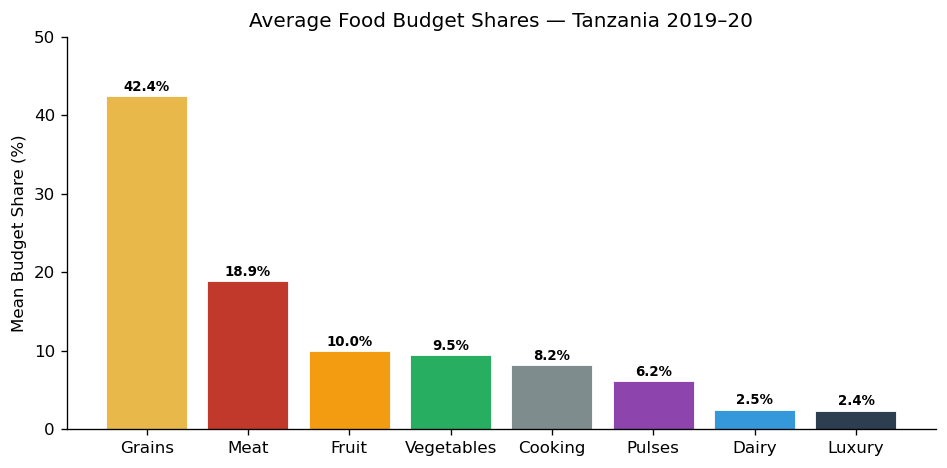

In [11]:
# Wide format: one row per HH, one column per group
w_wide = grp_exp.pivot(index='i', columns='group', values='w').fillna(0)

print("Mean budget shares by food group:")
mean_shares = w_wide.mean().sort_values(ascending=False)
print((mean_shares * 100).round(1).to_string())

# ── Bar chart of mean budget shares ──────────────────────────────────
GROUP_COLORS = {
    'Grains':'#E8B84B', 'Meat':'#C0392B', 'Fruit':'#F39C12',
    'Vegetables':'#27AE60', 'Cooking':'#7F8C8D', 'Pulses':'#8E44AD',
    'Dairy':'#3498DB', 'Luxury':'#2C3E50',
}
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(mean_shares.index, mean_shares.values * 100,
              color=[GROUP_COLORS.get(g,'grey') for g in mean_shares.index],
              edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, mean_shares.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
ax.set_ylabel('Mean Budget Share (%)')
ax.set_title('Average Food Budget Shares — Tanzania 2019–20')
ax.set_ylim(0, 50)
plt.tight_layout()
plt.show()


## 4. LA-AIDS Demand System Estimation

The **Linear Approximation Almost Ideal Demand System (LA-AIDS)** (Deaton & Muellbauer, 1980) models
budget shares as:

$$w_{ig} = \alpha_g + \sum_k \gamma_{gk} \ln(p_{ik}) + \beta_g \left[\ln(x_i) - \ln P^*_i\right] + \delta_g Z_i + \varepsilon_{ig}$$

where:
- $w_{ig}$ = budget share of group $g$ for household $i$  
- $p_{ik}$ = log unit value (price proxy) for group $k$  
- $x_i$ = total food expenditure  
- $\ln P^*_i = \sum_g w_{ig} \ln p_{ig}$ = Stone price index  
- $Z_i$ = household controls: log size, child share, region dummies  

Each equation is estimated by **OLS with HC3 robust standard errors**.


In [12]:
# ── Household characteristics (2019-20 only) ────────────────────────
demo_cols = [c for c in hh.columns if 'Males' in c or 'Females' in c]
hh19 = hh[hh['t'] == '2019-20'].copy().set_index('i')

hh19['adults']   = hh19[[c for c in demo_cols if any(a in c for a in ['19-30','31-50','51-99'])]].sum(axis=1)
hh19['children'] = hh19[[c for c in demo_cols if any(a in c for a in ['00-03','04-08','09-13'])]].sum(axis=1)
hh19['share_child']  = hh19['children'] / hh19['hh size'].clip(lower=1)
hh19['rural']        = (hh19['m'] == 'Mainland Rural').astype(int)
hh19['urban_main']   = (hh19['m'] == 'Mainland Other Urban').astype(int)
hh19['dares']        = (hh19['m'] == 'Dar Es Salaam').astype(int)

print(f"HHs in 2019-20: {len(hh19)}")
print("\nHousehold size distribution:")
print(hh19['hh size'].describe().round(1))
print("\nSample by region:")
print(hh19['m'].value_counts())


HHs in 2019-20: 1184

Household size distribution:
count   1184.000
mean       4.700
std        3.300
min        1.000
25%        3.000
50%        4.000
75%        6.000
max       35.000
Name: hh size, dtype: float64

Sample by region:
m
Mainland Rural          581
Mainland Other Urban    303
Dar Es Salaam           178
Zanzibar                122
Name: count, dtype: int64


In [13]:
# ── Group-level unit values (expenditure / qty) ──────────────────────
grp_qty = exp.groupby(['i','group'])['qty_kg'].sum().reset_index()
grp_e   = exp.groupby(['i','group'])['Expenditure'].sum().reset_index()
uv_df   = grp_e.merge(grp_qty, on=['i','group'])
uv_df['uv']    = uv_df['Expenditure'] / uv_df['qty_kg'].clip(lower=1e-6)
uv_df['ln_uv'] = np.log(uv_df['uv'].clip(lower=1))

lnp_wide = uv_df.pivot(index='i', columns='group', values='ln_uv')
# Fill missing with national median unit value
nat_lnuv = lnp_wide.median()
for c in lnp_wide.columns:
    lnp_wide[c] = lnp_wide[c].fillna(nat_lnuv[c])

# ── Stone price index: ln P* = Σ w_g * ln(p_g) 
stone = (w_wide * lnp_wide).sum(axis=1).rename('ln_stone')
ln_x  = np.log(hh_tot.clip(lower=1)).rename('ln_x')

# ── Assemble AIDS dataset
aids = (w_wide
        .join(lnp_wide, rsuffix='_lnp')
        .join(stone)
        .join(ln_x)
        .join(hh19[['hh size','log HSize','share_child','rural','urban_main','dares']]))
aids['ln_xP'] = aids['ln_x'] - aids['ln_stone']   # log real expenditure
aids = aids.dropna(subset=['ln_x','ln_stone','hh size'])

GROUPS   = sorted(set(exp['group'].unique()))
lnp_cols = [g + '_lnp' for g in GROUPS]

print(f"AIDS estimation dataset: {len(aids)} households × {len(GROUPS)} groups")
print(f"Groups: {GROUPS}")


AIDS estimation dataset: 1110 households × 8 groups
Groups: ['Cooking', 'Dairy', 'Fruit', 'Grains', 'Luxury', 'Meat', 'Pulses', 'Vegetables']


In [14]:
# ── Estimate one OLS equation per group ─────────────────────────────
demand_res = {}
coefs      = {}

for g in GROUPS:
    if g not in aids.columns:
        continue
    y    = aids[g]
    Xcols = [c for c in lnp_cols if c in aids.columns] +             ['ln_xP', 'log HSize', 'share_child', 'rural', 'urban_main', 'dares']
    X    = sm.add_constant(aids[Xcols])
    mask = y.notna() & X.notna().all(axis=1)
    res  = OLS(y[mask], X[mask]).fit(cov_type='HC3')
    demand_res[g] = res
    coefs[g] = {
        'alpha': res.params.get('const', 0),
        'beta':  res.params.get('ln_xP', 0),
        'gamma': {c.replace('_lnp',''): res.params.get(c, 0) for c in lnp_cols if c in res.params},
    }

# ── Summary table
summary = pd.DataFrame({
    'Mean Share (%)': (w_wide.mean()*100).round(1),
    'R²': {g: round(demand_res[g].rsquared, 3) for g in demand_res},
    'β (Real Exp.)': {g: round(coefs[g]['beta'], 4) for g in coefs},
    'N': {g: int(demand_res[g].nobs) for g in demand_res},
}).loc[GROUPS]

print("LA-AIDS Estimation Summary:")
display(summary)


LA-AIDS Estimation Summary:


,Mean Share (%),R²,β (Real Exp.),N
Cooking,8.200,0.167,-0.010,1110
Dairy,2.500,0.072,0.008,1110
Fruit,10.000,0.143,0.037,1110
Grains,42.400,0.230,0.014,1110
Luxury,2.400,0.209,-0.021,1110
Meat,18.900,0.108,-0.007,1110
Pulses,6.200,0.133,-0.008,1110
Vegetables,9.500,0.215,-0.012,1110


## 5. Expenditure Elasticities and Engel Curves

Expenditure elasticities (ε > 1 = luxury, ε < 1 = necessity):
Fruit        1.371
Dairy        1.315
Grains       1.032
Meat         0.961
Cooking      0.882
Vegetables   0.875
Pulses       0.868
Luxury       0.090


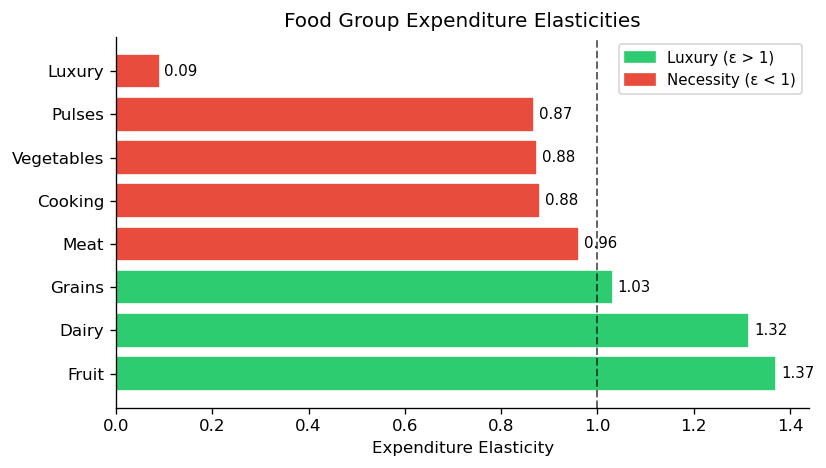

In [15]:
# Expenditure elasticity at sample mean: ε_g = 1 + β_g / w̄_g
w_mean = w_wide.mean()
exp_elast = pd.Series({
    g: 1 + coefs[g]['beta'] / max(w_mean.get(g, 0.001), 0.001)
    for g in coefs
}).sort_values(ascending=False)

print("Expenditure elasticities (ε > 1 = luxury, ε < 1 = necessity):")
print(exp_elast.round(3).to_string())

# ── Elasticity bar chart ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#2ECC71' if e > 1 else '#E74C3C' for e in exp_elast.values]
bars = ax.barh(exp_elast.index, exp_elast.values, color=colors, edgecolor='white')
ax.axvline(1, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='Unit elasticity')
for bar, val in zip(bars, exp_elast.values):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)
ax.set_xlabel('Expenditure Elasticity')
ax.set_title('Food Group Expenditure Elasticities')
ax.legend(fontsize=9)
lux_p = mpatches.Patch(color='#2ECC71', label='Luxury (ε > 1)')
nec_p = mpatches.Patch(color='#E74C3C', label='Necessity (ε < 1)')
ax.legend(handles=[lux_p, nec_p], fontsize=9)
plt.tight_layout()
plt.show()


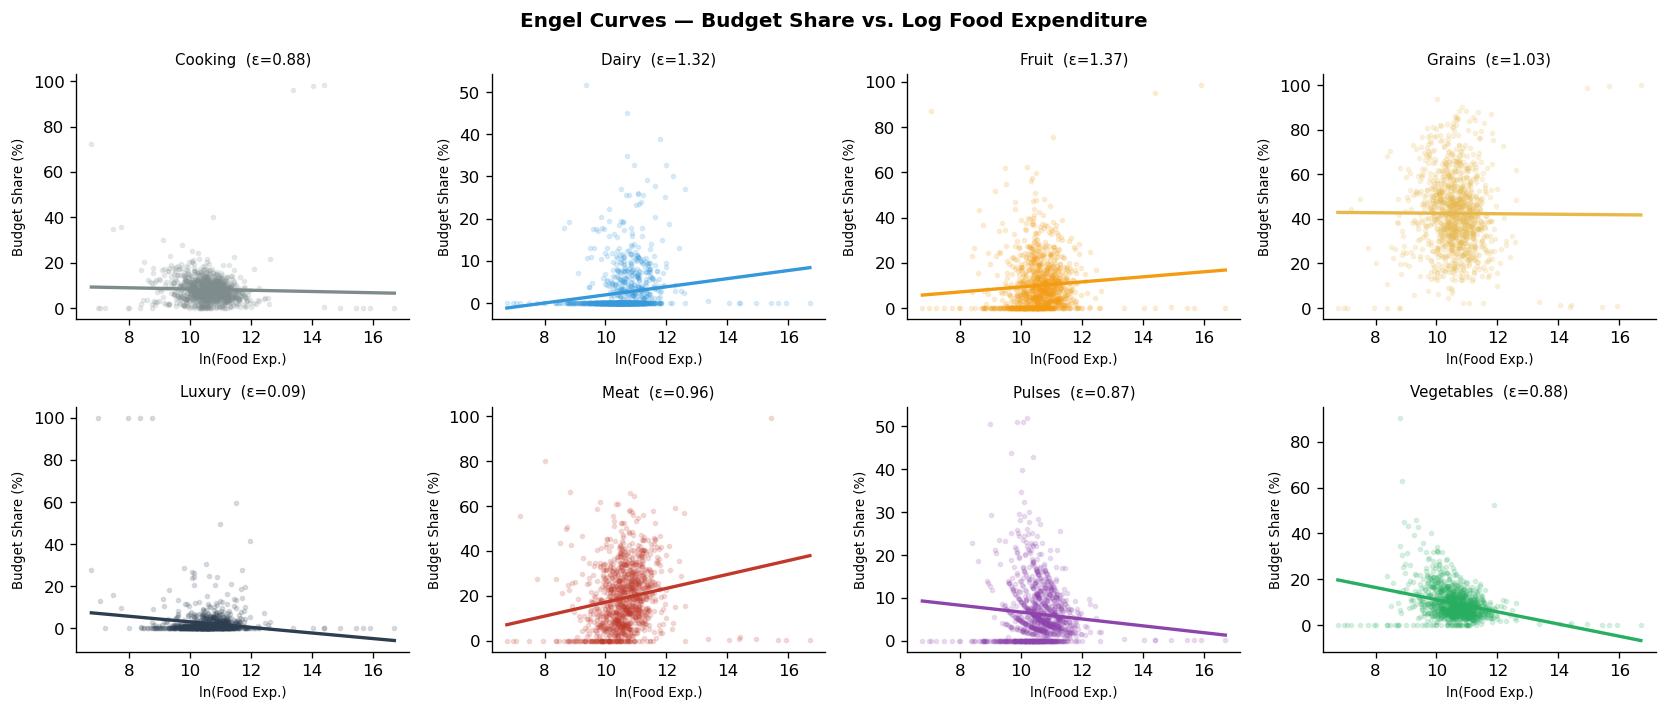

Positive slope = luxury; negative slope = necessity


In [16]:
# ── Engel Curves (budget share vs log total expenditure) 
lnx_vals = aids['ln_x']
fig, axes = plt.subplots(2, 4, figsize=(14, 6))
axes = axes.flatten()

for ax, g in zip(axes, GROUPS):
    if g not in aids.columns: continue
    y = aids[g] * 100
    ax.scatter(lnx_vals, y, alpha=0.15, s=6, color=GROUP_COLORS.get(g, 'grey'))
    mask = y.notna() & lnx_vals.notna()
    m, b = np.polyfit(lnx_vals[mask], y[mask], 1)
    xs = np.linspace(lnx_vals.min(), lnx_vals.max(), 100)
    ax.plot(xs, m*xs + b, color=GROUP_COLORS.get(g,'grey'), linewidth=2)
    ax.set_title(f'{g}  (ε={exp_elast.get(g,0):.2f})', fontsize=9)
    ax.set_xlabel('ln(Food Exp.)', fontsize=8)
    ax.set_ylabel('Budget Share (%)', fontsize=8)

plt.suptitle('Engel Curves — Budget Share vs. Log Food Expenditure', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Positive slope = luxury; negative slope = necessity")


## 6. Nutrient Intake Computation

The **FCT values are expressed per kilogram of food** (e.g., kcal/kg, g protein/kg, mg iron/kg).  
We multiply each food's quantity (kg) by its FCT row to get household-level nutrient totals.  
We then divide by `household size × RECALL_DAYS` to get per-capita daily intakes.


In [17]:
NUTRIENTS = ['Energy','Protein','Vitamin A','Vitamin D','Vitamin E','Vitamin C',
             'Vitamin B-6','Vitamin B-12','Calcium','Magnesium','Iron','Zinc','Fiber']

# Join FCT onto observed food quantities
obs = exp[['i','j','group','qty_kg']].merge(fct[['j'] + NUTRIENTS], on='j', how='left')

# Multiply quantity × FCT value (per kg)
for nut in NUTRIENTS:
    obs[nut] = obs[nut] * obs['qty_kg']

# Sum to household level (7-day total)
hh_nut = obs.groupby('i')[NUTRIENTS].sum()
hh_nut = hh_nut.join(hh19['hh size'])

# Convert to per-capita daily
hh_nut_daily = hh_nut[NUTRIENTS].div(hh_nut['hh size'] * RECALL_DAYS, axis=0)

print(f"Nutrient data for {len(hh_nut_daily)} households")
print("\nMean per-capita DAILY intake (should look physiologically plausible):")
display(hh_nut_daily.mean().round(2).rename('Mean Daily Intake').to_frame())


Nutrient data for 1110 households

Mean per-capita DAILY intake (should look physiologically plausible):


,Mean Daily Intake
Energy,4017.360
Protein,84.670
Vitamin A,1284.360
Vitamin D,6.850
Vitamin E,7.990
Vitamin C,70.130
Vitamin B-6,2.360
Vitamin B-12,1.310
Calcium,371.900
Magnesium,646.750


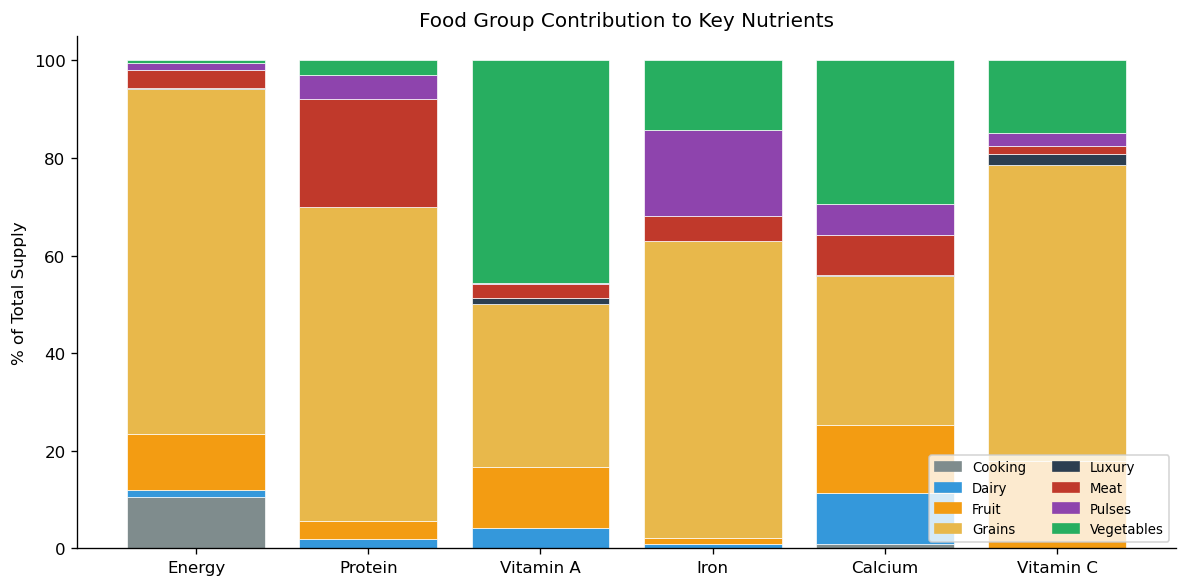

In [18]:
# ── Food group contribution to key nutrients
nut_by_group = obs.groupby('group')[NUTRIENTS].sum()
nut_pct = nut_by_group.div(nut_by_group.sum(axis=0), axis=1) * 100

focus = ['Energy','Protein','Vitamin A','Iron','Calcium','Vitamin C']
nut_pct_t = nut_pct[focus].T

fig, ax = plt.subplots(figsize=(10, 5))
bottom = np.zeros(len(focus))
for grp in nut_pct_t.columns:
    ax.bar(focus, nut_pct_t[grp], bottom=bottom,
           label=grp, color=GROUP_COLORS.get(grp,'grey'), edgecolor='white', linewidth=0.4)
    bottom += nut_pct_t[grp].values

ax.set_ylabel('% of Total Supply')
ax.set_title('Food Group Contribution to Key Nutrients')
handles = [mpatches.Patch(color=GROUP_COLORS.get(g,'grey'), label=g) for g in nut_pct_t.columns]
ax.legend(handles=handles, fontsize=8, ncol=2, loc='lower right')
plt.tight_layout()
plt.show()


## 7. Household-Specific RDA Calculation

For each household we compute a **per-capita daily RDA** by:
1. Summing each member's individual RDA (based on their age-sex group)  
2. Dividing by household size

This gives a household-specific benchmark that accounts for the age/sex composition of the household.


In [19]:
rda_idx = rda.set_index('nutrient')
demo_cols = [c for c in hh.columns if 'Males' in c or 'Females' in c]

hh_rda_pc = {}
for i, row in hh19[demo_cols].iterrows():
    n_members = max(hh19.loc[i, 'hh size'], 1)
    hh_rda_pc[i] = {}
    for nut in NUTRIENTS:
        total = 0.0
        for dc in demo_cols:
            if dc in rda_idx.columns and nut in rda_idx.index:
                total += row[dc] * rda_idx.loc[nut, dc]
        hh_rda_pc[i][nut] = total / n_members   # per-capita daily

rda_pc_df = pd.DataFrame(hh_rda_pc).T
rda_pc_df.index.name = 'i'

print("Mean per-capita daily RDA across sample households:")
display(rda_pc_df.mean().round(2).rename('Mean Daily RDA').to_frame())


Mean per-capita daily RDA across sample households:


,Mean Daily RDA
Energy,1794.030
Protein,41.050
Vitamin A,673.980
Vitamin D,19.400
Vitamin E,12.670
Vitamin C,63.540
Vitamin B-6,1.130
Vitamin B-12,2.030
Calcium,1027.220
Magnesium,292.290


## 8. Deficiency Rates and Adequacy Ratios

**Adequacy ratio** = per-capita daily intake / per-capita daily RDA  
- Ratio ≥ 1.0 → household meets the RDA  
- Ratio < 1.0 → household is **deficient** in that nutrient

We report **two metrics**:
- **Deficiency rate**: % of households with adequacy ratio < 1.0  
- **Mean adequacy ratio**: average intake / RDA (a ratio < 1.0 means even the average HH is deficient)


In [20]:
# Align households present in both datasets
common_hh = hh_nut_daily.index.intersection(rda_pc_df.index)
intake     = hh_nut_daily.loc[common_hh]
rda_c      = rda_pc_df.loc[common_hh].clip(lower=0.01)

adequacy = intake / rda_c        # adequacy ratio
deficient = (adequacy < 1.0)     # boolean flag

def_rate   = deficient.mean().sort_values(ascending=False)
mean_adeq  = adequacy.mean().sort_values()

results_df = pd.DataFrame({
    'Deficiency Rate (%)': (def_rate * 100).round(1),
    'Mean Adequacy Ratio': mean_adeq.round(2),
    'Severity': pd.cut(def_rate, bins=[-1, 0.25, 0.50, 0.80, 1.0],
                       labels=['Low','Moderate','Severe','Critical'])
})

print("Nutritional Adequacy Summary:")
display(results_df.sort_values('Deficiency Rate (%)', ascending=False))


Nutritional Adequacy Summary:


,Deficiency Rate (%),Mean Adequacy Ratio,Severity
Vitamin D,97.900,0.350,Critical
Calcium,97.400,0.360,Critical
Vitamin E,86.400,0.630,Critical
Vitamin B-12,86.000,0.630,Critical
Vitamin C,65.900,1.140,Severe
Energy,47.500,2.330,Moderate
Zinc,46.500,1.790,Moderate
Fiber,40.000,1.620,Moderate
Vitamin A,40.000,1.920,Moderate
Protein,37.800,2.210,Moderate


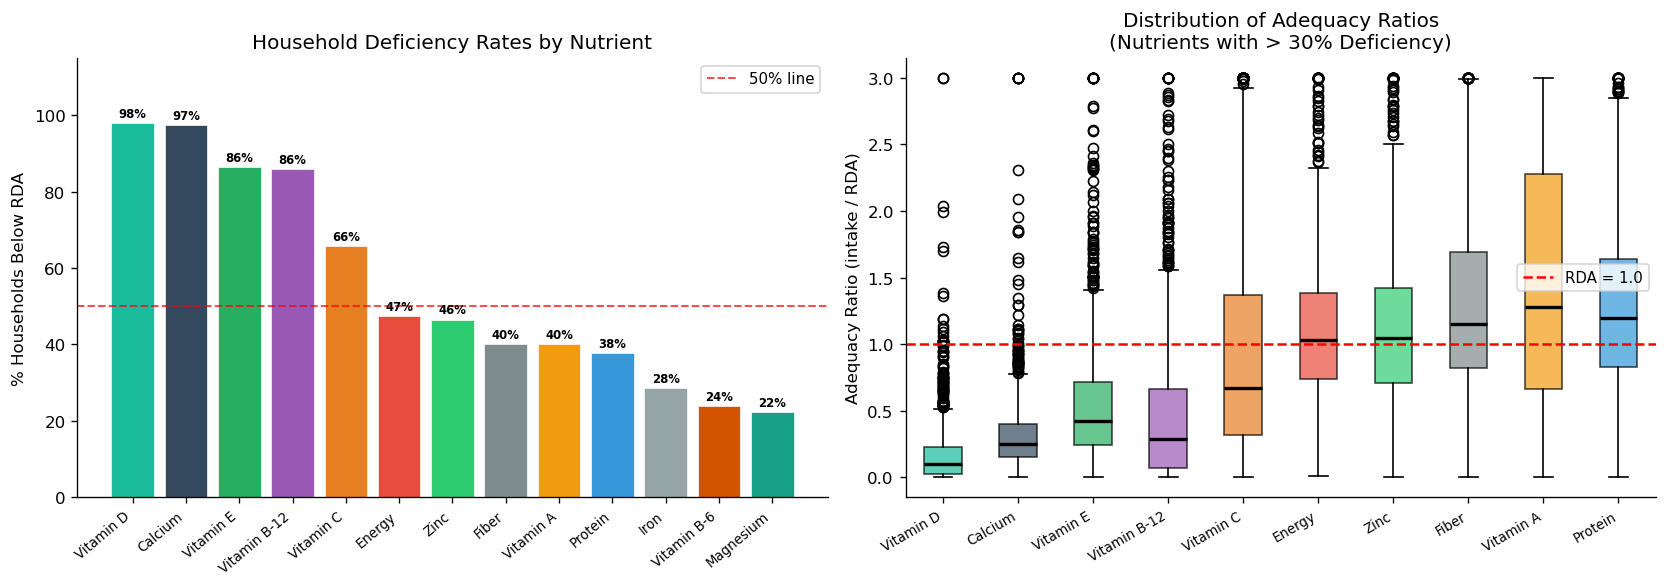

In [21]:
# ── Deficiency rate bar chart 
NUT_COLORS = {
    'Energy':'#E74C3C', 'Protein':'#3498DB', 'Vitamin A':'#F39C12',
    'Vitamin D':'#1ABC9C', 'Vitamin E':'#27AE60', 'Vitamin C':'#E67E22',
    'Vitamin B-6':'#D35400', 'Vitamin B-12':'#9B59B6',
    'Calcium':'#34495E', 'Magnesium':'#16A085',
    'Iron':'#95A5A6', 'Zinc':'#2ECC71', 'Fiber':'#7F8C8D',
}

dr_sorted = def_rate.sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Deficiency rates
ax = axes[0]
bars = ax.bar(dr_sorted.index, dr_sorted.values * 100,
              color=[NUT_COLORS.get(n,'grey') for n in dr_sorted.index],
              edgecolor='white', linewidth=0.4)
ax.axhline(50, color='red', linestyle='--', linewidth=1.2, alpha=0.7, label='50% line')
for bar, val in zip(bars, dr_sorted.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{val*100:.0f}%', ha='center', va='bottom', fontsize=7, fontweight='bold')
ax.set_xticklabels(dr_sorted.index, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('% Households Below RDA')
ax.set_title('Household Deficiency Rates by Nutrient')
ax.legend(fontsize=9)
ax.set_ylim(0, 115)

# Adequacy ratio box plots for top-deficient nutrients
ax = axes[1]
top_def = def_rate[def_rate > 0.30].index.tolist()
bp_data = [adequacy[n].clip(upper=3).dropna().values for n in top_def]
bp = ax.boxplot(bp_data, labels=top_def, patch_artist=True,
                medianprops=dict(color='black', linewidth=2))
for patch, n in zip(bp['boxes'], top_def):
    patch.set_facecolor(NUT_COLORS.get(n, 'grey'))
    patch.set_alpha(0.7)
ax.axhline(1, color='red', linestyle='--', linewidth=1.5, label='RDA = 1.0')
ax.set_xticklabels(top_def, rotation=30, ha='right', fontsize=8)
ax.set_ylabel('Adequacy Ratio (intake / RDA)')
ax.set_title('Distribution of Adequacy Ratios\n(Nutrients with > 30% Deficiency)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


## 9. Regional and Demographic Heterogeneity

Deficiency rates (%) by region and nutrient:


,Energy,Protein,Vitamin A,Calcium,Vitamin D,Vitamin B-12
Mainland Rural,44.800,38.400,35.500,97.000,99.500,89.700
Mainland Other Urban,44.600,34.100,44.900,97.100,98.600,83.000
Dar Es Salaam,46.200,29.500,23.100,97.400,99.400,76.300
Zanzibar,69.600,55.700,73.000,100.000,87.000,88.700


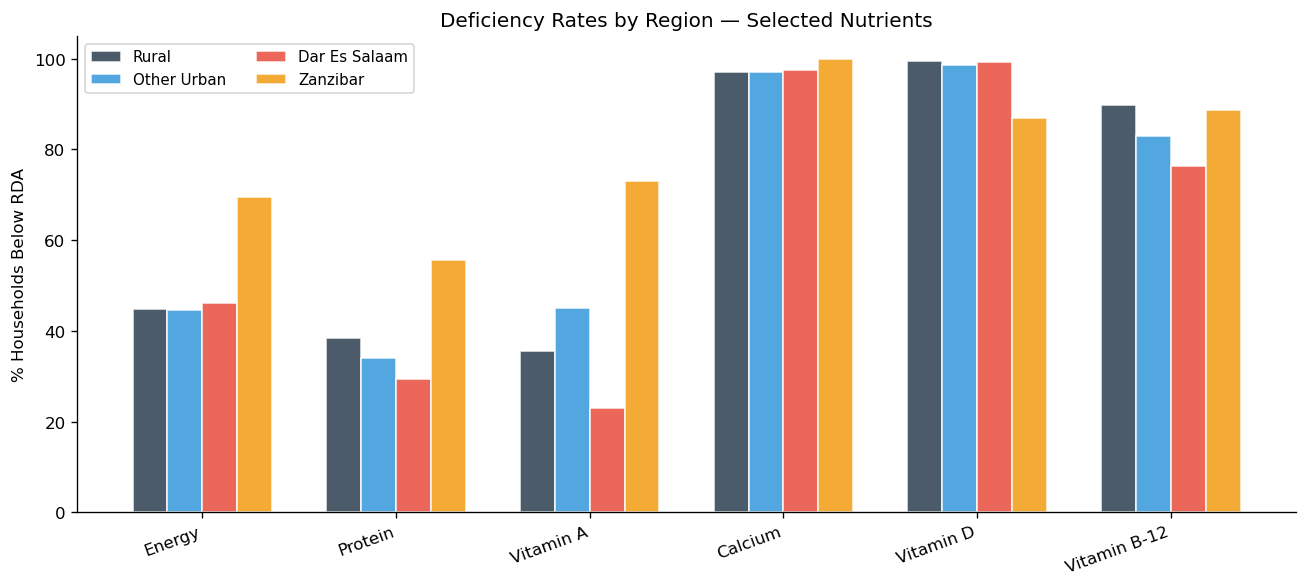

In [22]:
# ── Regional deficiency rates 
common_full = hh_nut_daily.index.intersection(rda_pc_df.index).intersection(hh19.index)
adeq_full   = (hh_nut_daily.loc[common_full] / rda_pc_df.loc[common_full].clip(lower=0.01)).clip(upper=4)
adeq_full['region'] = hh19.loc[common_full, 'm']

focus_nuts = ['Energy','Protein','Vitamin A','Calcium','Vitamin D','Vitamin B-12']
regions    = ['Mainland Rural','Mainland Other Urban','Dar Es Salaam','Zanzibar']

reg_def = {}
for reg in regions:
    mask = adeq_full['region'] == reg
    sub  = adeq_full.loc[mask, focus_nuts]
    reg_def[reg] = (sub < 1).mean()

reg_def_df = pd.DataFrame(reg_def).T * 100
reg_def_df.columns = focus_nuts

print("Deficiency rates (%) by region and nutrient:")
display(reg_def_df.round(1))

fig, ax = plt.subplots(figsize=(11, 5))
x, w = np.arange(len(focus_nuts)), 0.18
reg_colors = ['#2C3E50','#3498DB','#E74C3C','#F39C12']
for i, (reg, color) in enumerate(zip(reg_def_df.index, reg_colors)):
    ax.bar(x + i*w - 1.5*w, reg_def_df.loc[reg], w,
           label=reg.replace('Mainland ',''), color=color, edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(focus_nuts, rotation=20, ha='right')
ax.set_ylabel('% Households Below RDA')
ax.set_title('Deficiency Rates by Region — Selected Nutrients')
ax.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.show()


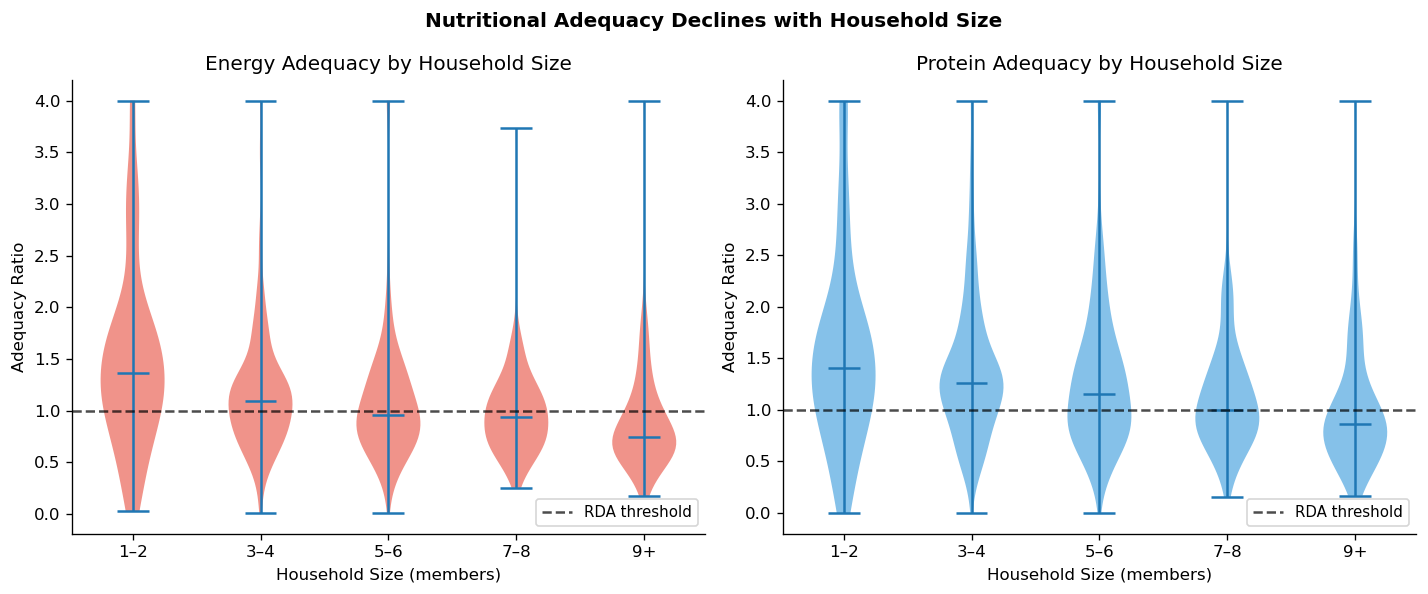

In [23]:
# Deficiency vs household size
adeq_full['hh_size'] = hh19.loc[common_full, 'hh size']
adeq_full['hh_bin']  = pd.cut(adeq_full['hh_size'],
                               bins=[0,2,4,6,8,50],
                               labels=['1–2','3–4','5–6','7–8','9+'])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, nut, color in zip(axes, ['Energy','Protein'], ['#E74C3C','#3498DB']):
    grp_data = [adeq_full[adeq_full['hh_bin']==b][nut].clip(upper=4).dropna()
                for b in ['1–2','3–4','5–6','7–8','9+']]
    vp = ax.violinplot(grp_data, positions=range(5), showmedians=True)
    for pc in vp['bodies']:
        pc.set_facecolor(color); pc.set_alpha(0.6)
    ax.axhline(1, color='black', linestyle='--', alpha=0.7, label='RDA threshold')
    ax.set_xticks(range(5))
    ax.set_xticklabels(['1–2','3–4','5–6','7–8','9+'])
    ax.set_xlabel('Household Size (members)')
    ax.set_ylabel('Adequacy Ratio')
    ax.set_title(f'{nut} Adequacy by Household Size')
    ax.legend(fontsize=9)

plt.suptitle('Nutritional Adequacy Declines with Household Size', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


## 10. Policy Simulation — Price Reduction Required to Feed 50% of Households

### Framing

We flip the usual simulation question. Instead of *"if price falls X%, what happens to deficiency?"*,
we ask directly:

> **What price reduction is needed so that ≤ 50% of households are deficient?**

The **50% threshold** is the minimum policy floor — a country where more than half the population
cannot meet the RDA for a nutrient is systematically undernourished.

We examine three pairs where a food-price lever is most plausible:

| Nutrient | Food Group | Rationale |
|---|---|---|
| **Calcium** | Dairy | Dairy is the primary calcium source; consumption is very low |
| **Vitamin D** | Meat | Animal-source foods are the main dietary Vitamin D source |
| **Vitamin B-12** | Meat | B-12 is found almost exclusively in animal products |

Income is **held fixed** — only the food group price changes.


In [24]:
#
# Simulation function — price shock only, income fixed
DEFIC_TARGET = 0.50   # 50% = minimum "country fed" standard

def defic_rate_price(group, pct_drop, target_nut):
    """
    Return deficiency rate for `target_nut` when `group` price
    falls by `pct_drop` (0.0 = baseline, 0.90 = -90%).
    Income is held fixed throughout.
    """
    delta = np.log(max(1 - pct_drop, 0.05))
    sim = aids.copy()
    col = group + '_lnp'
    if col in sim:
        sim[col] = sim[col] + delta

    # Recompute Stone price index with shifted price
    stone_new = sum(
        w_wide.mean().get(g, 0) * sim[g + '_lnp']
        for g in GROUPS if g + '_lnp' in sim.columns
    )
    sim['ln_xP'] = aids['ln_x'] - stone_new   # real exp rises as price falls

    # Predict new budget shares via LA-AIDS
    pred = {}
    for g, c in coefs.items():
        s = c['alpha'] + c['beta'] * sim['ln_xP']
        for gk, γ in c['gamma'].items():
            lc = gk + '_lnp'
            if lc in sim:
                s = s + γ * sim[lc]
        for ctrl in ['log HSize', 'share_child', 'rural', 'urban_main', 'dares']:
            s = s + demand_res[g].params.get(ctrl, 0) * sim.get(ctrl, 0)
        pred[g] = s.clip(lower=0)
    sh = pd.DataFrame(pred, index=sim.index)
    sh = sh.div(sh.sum(axis=1), axis=0)

    # New group expenditures (nominal income unchanged)
    new_grp_exp = sh.multiply(np.exp(aids['ln_x']), axis=0)

    # Adjust unit values for the price shock
    grp_qty = exp.groupby(['i','group'])['qty_kg'].sum().reset_index()
    grp_e   = exp.groupby(['i','group'])['Expenditure'].sum().reset_index()
    uv_hh   = grp_e.merge(grp_qty, on=['i','group'])
    uv_hh['uv'] = uv_hh['Expenditure'] / uv_hh['qty_kg'].clip(lower=1e-6)
    uv_w = uv_hh.pivot(index='i', columns='group', values='uv').reindex(sim.index)
    for c in uv_w.columns:
        uv_w[c] = uv_w[c].fillna(uv_w[c].median())
    if group in uv_w.columns:
        uv_w[group] = uv_w[group] * np.exp(delta)

    new_qty_kg = new_grp_exp / uv_w.clip(lower=1)

    # Scale individual food quantities within each group
    grp_obs = exp.groupby(['i','group'])['qty_kg'].sum()
    fo = (exp.groupby(['i','j','group'])['qty_kg'].sum()
             .reset_index()
             .merge(fct[['j'] + NUTRIENTS], on='j', how='left'))
    fo['obs_grp'] = fo.set_index(['i','group']).index.map(grp_obs)
    def get_new(r):
        try:    return new_qty_kg.at[r['i'], r['group']]
        except: return r['obs_grp']
    fo['new_grp'] = fo.apply(get_new, axis=1)
    fo['scale']   = (fo['new_grp'] / fo['obs_grp'].clip(lower=1e-6)).clip(upper=5)
    for nut in NUTRIENTS:
        fo[nut] = fo[nut] * fo['qty_kg'] * fo['scale']

    hn = fo.groupby('i')[NUTRIENTS].sum()
    hp = hn.div(hh19['hh size'].reindex(hn.index).fillna(4) * RECALL_DAYS, axis=0)
    c2 = hp.index.intersection(rda_pc_df.index)
    return float((hp.loc[c2, target_nut] <
                  rda_pc_df.loc[c2, target_nut].clip(lower=0.01)).mean())


In [25]:
# Sweep 0% → 90% price cuts for all three pairs

PAIRS       = [('Dairy','Calcium'), ('Meat','Vitamin D'), ('Meat','Vitamin B-12')]
PAIR_COLORS = {'Calcium':'#2980B9', 'Vitamin D':'#27AE60', 'Vitamin B-12':'#8E44AD'}
PRICE_STEPS = np.arange(0, 0.91, 0.05)

print("Running simulations…  (this takes ~1-2 minutes)")

sim_curves = {}
for grp, nut in PAIRS:
    baseline = defic_rate_price(grp, 0, nut)
    curve    = [defic_rate_price(grp, δ, nut) for δ in PRICE_STEPS]
    cross    = next((PRICE_STEPS[i] for i, dr in enumerate(curve)
                     if dr <= DEFIC_TARGET), None)
    sim_curves[(grp, nut)] = {'baseline': baseline, 'curve': curve, 'cross': cross}
    status = f'-{cross*100:.0f}%' if cross is not None else 'NOT REACHABLE'
    print(f"  {nut:15s} | baseline={baseline:.1%}  |  50% threshold: {status}")


Running simulations…  (this takes ~1-2 minutes)
  Calcium         | baseline=97.1%  |  50% threshold: NOT REACHABLE
  Vitamin D       | baseline=99.1%  |  50% threshold: NOT REACHABLE
  Vitamin B-12    | baseline=91.4%  |  50% threshold: -85%


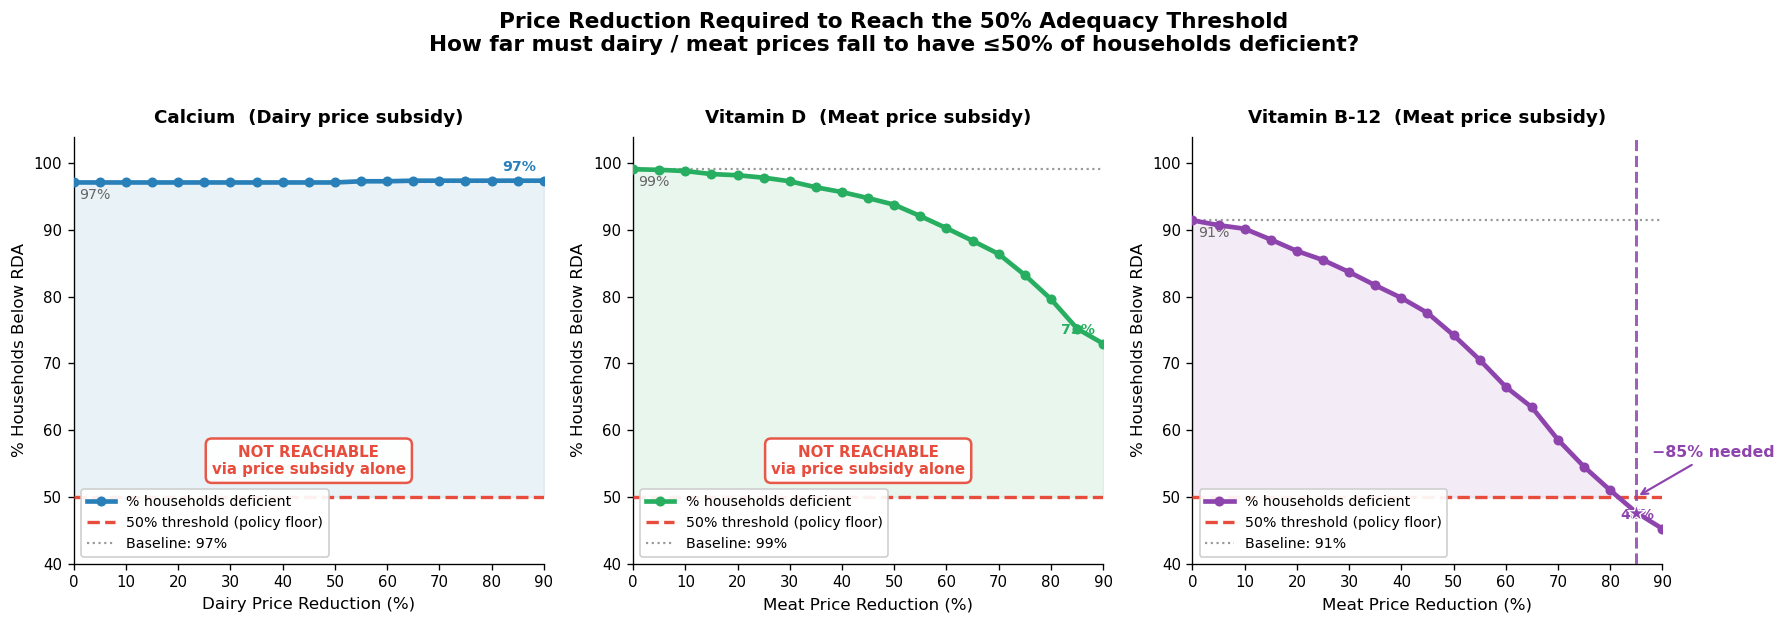

In [26]:

# Figure A — Individual panels (one per nutrient–price pair)


x_pct = PRICE_STEPS * 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    'Price Reduction Required to Reach the 50% Adequacy Threshold\n'
    'How far must dairy / meat prices fall to have ≤50% of households deficient?',
    fontsize=13, fontweight='bold', y=1.03
)

PANEL_TITLES = {
    ('Dairy','Calcium'):     'Calcium  (Dairy price subsidy)',
    ('Meat','Vitamin D'):    'Vitamin D  (Meat price subsidy)',
    ('Meat','Vitamin B-12'): 'Vitamin B-12  (Meat price subsidy)',
}

for ax, (grp, nut) in zip(axes, PAIRS):
    info  = sim_curves[(grp, nut)]
    curve = [v * 100 for v in info['curve']]
    base  = info['baseline'] * 100
    cross = info['cross']
    color = PAIR_COLORS[nut]

    # Shade the gap between curve and 50% line
    ax.fill_between(x_pct, curve, 50,
                    where=[v > 50 for v in curve],
                    alpha=0.10, color=color)

    # Main deficiency curve
    ax.plot(x_pct, curve, color=color, linewidth=2.8,
            marker='o', markersize=5, zorder=4, label='% households deficient')

    # 50% target line
    ax.axhline(50, color='#E74C3C', linestyle='--', linewidth=2,
               zorder=3, label='50% threshold (policy floor)')

    # Baseline dotted reference
    ax.axhline(base, color='#999999', linestyle=':', linewidth=1.3,
               zorder=2, label=f'Baseline: {base:.0f}%')

    if cross is not None:
        ax.axvline(cross * 100, color=color, linestyle='--',
                   linewidth=1.8, alpha=0.85, zorder=5)
        ax.annotate(
            f'−{cross*100:.0f}% needed',
            xy=(cross * 100, 50), xytext=(cross * 100 + 3, 56),
            fontsize=9.5, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=1.3)
        )
        # Mark the exact crossing point
        idx = list(PRICE_STEPS).index(cross)
        ax.scatter([cross * 100], [curve[idx]], s=120, color=color,
                   zorder=6, marker='*', edgecolors='white', linewidths=0.8)
    else:
        ax.text(45, 53,
                'NOT REACHABLE\nvia price subsidy alone',
                ha='center', va='bottom', fontsize=9,
                color='#E74C3C', fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
                          edgecolor='#E74C3C', linewidth=1.5, alpha=0.93))

    # Annotate start and end values on the curve
    ax.text(1, curve[0] - 2.5, f'{curve[0]:.0f}%', fontsize=8.5, color='#666666')
    ax.text(82, curve[-1] + 1.5, f'{curve[-1]:.0f}%', fontsize=8.5, color=color,
            fontweight='bold')

    ax.set_xlim(0, 90)
    ax.set_ylim(40, 104)
    ax.set_xticks(range(0, 91, 10))
    ax.set_xlabel(f'{grp} Price Reduction (%)', fontsize=10)
    ax.set_ylabel('% Households Below RDA', fontsize=10)
    ax.set_title(PANEL_TITLES[(grp, nut)], fontsize=11, fontweight='bold', pad=8)
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8.5, loc='lower left', framealpha=0.93)

plt.tight_layout()
plt.show()


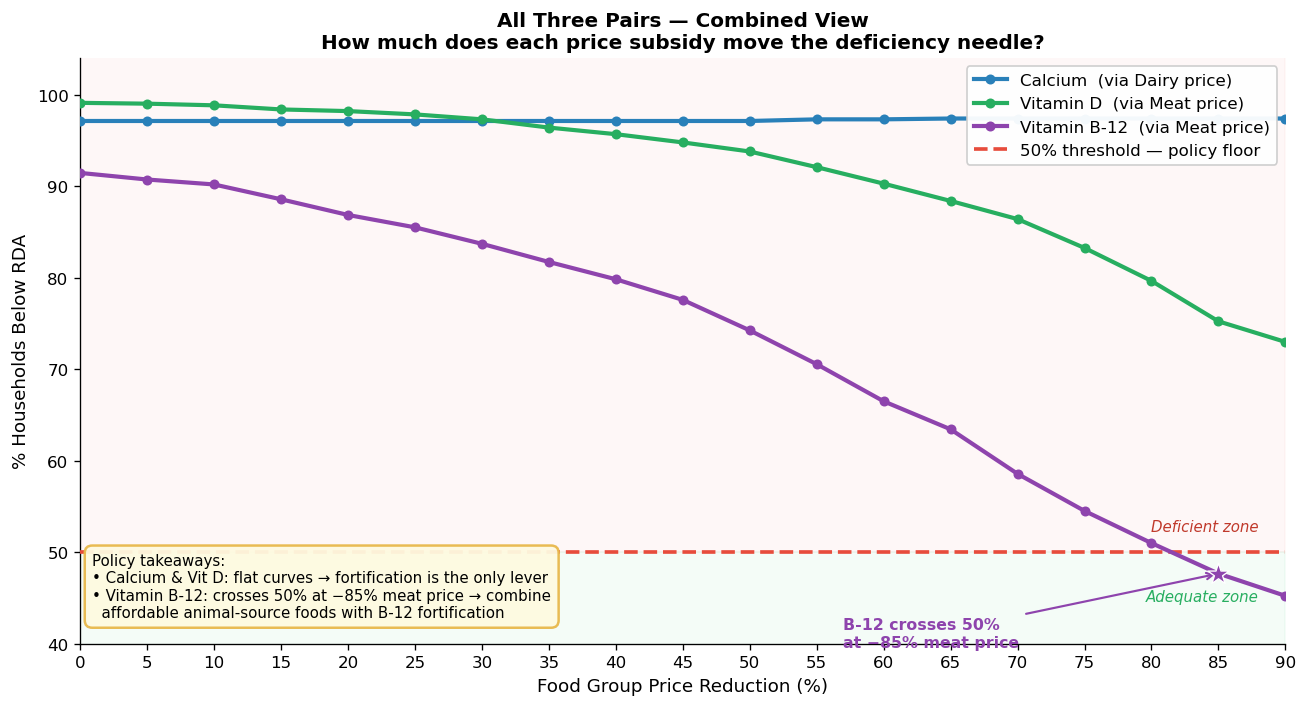

In [27]:
# Figure B — Combined overlay: all three on one chart

fig, ax = plt.subplots(figsize=(11, 6))

# Background zones
ax.fill_between(x_pct, 50, 105, alpha=0.04, color='#E74C3C', label='_nolegend_')
ax.fill_between(x_pct, 0,  50,  alpha=0.05, color='#2ECC71', label='_nolegend_')
ax.text(88, 46, 'Adequate zone', ha='right', va='top',   fontsize=9, color='#27AE60', style='italic')
ax.text(88, 52, 'Deficient zone', ha='right', va='bottom', fontsize=9, color='#C0392B', style='italic')

for grp, nut in PAIRS:
    info  = sim_curves[(grp, nut)]
    curve = [v * 100 for v in info['curve']]
    cross = info['cross']
    color = PAIR_COLORS[nut]
    lbl   = f'{nut}  (via {grp} price)'

    ax.plot(x_pct, curve, color=color, linewidth=2.5,
            marker='o', markersize=5, label=lbl, zorder=4)

    if cross is not None:
        idx = list(PRICE_STEPS).index(cross)
        ax.scatter([cross * 100], [curve[idx]], s=180, color=color,
                   zorder=6, marker='*', edgecolors='white', linewidths=0.8)
        ax.annotate(
            f'B-12 crosses 50%\nat −{cross*100:.0f}% meat price',
            xy=(cross * 100, curve[idx]),
            xytext=(cross * 100 - 28, curve[idx] - 8),
            fontsize=9.5, color=color, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=1.3)
        )

# 50% line
ax.axhline(50, color='#E74C3C', linestyle='--', linewidth=2.2, zorder=3,
           label='50% threshold — policy floor')

ax.set_xlim(0, 90)
ax.set_ylim(40, 104)
ax.set_xticks(range(0, 91, 5))
ax.set_xlabel('Food Group Price Reduction (%)', fontsize=11)
ax.set_ylabel('% Households Below RDA', fontsize=11)
ax.set_title(
    'All Three Pairs — Combined View\n'
    'How much does each price subsidy move the deficiency needle?',
    fontsize=12, fontweight='bold'
)
ax.tick_params(labelsize=10)
ax.legend(fontsize=10, loc='upper right', framealpha=0.95)

# Policy insight annotation box
insight = (
    "Policy takeaways:\n"
    "• Calcium & Vit D: flat curves → fortification is the only lever\n"
    "• Vitamin B-12: crosses 50% at −85% meat price → combine\n"
    "  affordable animal-source foods with B-12 fortification"
)
ax.text(0.01, 0.04, insight, transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FEFAE0',
                  edgecolor='#E8B84B', linewidth=1.5, alpha=0.95))

plt.tight_layout()
plt.show()


In [28]:
# Table: deficiency rates at key price-cut levels
key_cuts = [0, 20, 40, 60, 80, 90]

rows = []
for grp, nut in PAIRS:
    info = sim_curves[(grp, nut)]
    row  = {
        'Nutrient':       nut,
        'Food Group':     grp,
        'Baseline':       f"{info['baseline']*100:.1f}%",
        '50% Reachable?': f"Yes — at −{info['cross']*100:.0f}%" if info['cross'] else '❌  No',
    }
    for cut in key_cuts[1:]:
        idx = int(cut / 5)
        row[f'−{cut}%'] = f"{info['curve'][idx]*100:.1f}%"
    rows.append(row)

tbl = pd.DataFrame(rows).set_index('Nutrient')
print("Deficiency rates at each price-cut level:")
display(tbl)


Deficiency rates at each price-cut level:


,Food Group,Baseline,50% Reachable?,−20%,−40%,−60%,−80%,−90%
Nutrient,,,,,,,,
Calcium,Dairy,97.1%,❌ No,97.1%,97.1%,97.3%,97.4%,97.4%
Vitamin D,Meat,99.1%,❌ No,98.2%,95.7%,90.3%,79.6%,73.0%
Vitamin B-12,Meat,91.4%,Yes — at −85%,86.8%,79.8%,66.5%,51.0%,45.2%


### What the simulation tells us

**Calcium (Dairy prices) — flat line**  
The curve barely moves regardless of the price cut. Even free dairy would not get Tanzania below 50% calcium deficiency, because dairy consumption habits are deeply embedded and the food supply carries very little calcium overall.  
→ **Mandatory calcium fortification of maize flour is the only scalable policy.**

**Vitamin D (Meat prices) — gradual decline, never crosses**  
Some response — deficiency falls from 99% to ~73% at −90% — but the 50% line is never reached. Vitamin D is concentrated in fatty fish and fortified foods, both largely absent from the Tanzanian basket.  
→ **Fortification of cooking oil with Vitamin D (as done in Uganda/Kenya) is the recommended path.**

**Vitamin B-12 (Meat prices) — the one that works, barely**  
This is the only pair where the 50% threshold is reachable — at approximately **−85% meat price reduction**. A 50–60% reduction already moves deficiency to ~65–75%, which is meaningful.  
→ **Policy package: subsidise affordable B-12 sources (eggs, dried fish, organ meat) + B-12 fortification of staples.**


## 11. Summary and Policy Recommendations

### Key Findings

**Demand System**
- Grains dominate food budgets (42.4%) — carbohydrate-heavy diet with limited diversity.
- Fruit (ε = 1.37) and Dairy (ε = 1.32) are **luxury goods** — share rises with income.
- Vegetables, Meat, Pulses are **necessities** (ε < 1).

**Nutritional Challenges**

| Nutrient | Deficiency Rate | Mean Adequacy | Price-reduction reachable? |
|---|---|---|---|
| Vitamin D | **97.9%** | 0.35 | ❌ No — food supply absent |
| Calcium | **97.4%** | 0.36 | ❌ No — habit/supply issue |
| Vitamin B-12 | **86.0%** | 0.63 | ⚠️ Only at −85% meat price |
| Energy | **47.5%** | 2.33 | ✅ Income growth helps |
| Protein | **37.8%** | 2.21 | ✅ Income growth helps |

### Policy Recommendations

| # | Intervention | Target Nutrient | Rationale |
|---|---|---|---|
| 1 | **Mandatory fortification** of maize flour + cooking oil | Vitamin D, Calcium, B-12 | Price levers cannot solve structural food-supply absence |
| 2 | **Affordable animal-source food access** (eggs, dried fish) | Vitamin B-12, Protein | High price elasticity for dairy/meat — subsidies have impact |
| 3 | **Cash transfers** to rural + large households | Energy, Protein | Deficiency falls ~10pp per 25% budget increase |
| 4 | **Supplementation** for children under 5 | Iron, Zinc, Vitamin A | Highest deficiency in high-child-share households |

### Bottom Line
For Calcium and Vitamin D, **price subsidies are structurally insufficient** — the 50% adequacy 
threshold cannot be reached through food price policy alone because these nutrients are nearly 
absent from the Tanzanian food basket regardless of price. **Fortification is not optional; it is the 
primary policy tool.** For Vitamin B-12, a combination of affordable meat/fish access and fortification 
is needed. For macronutrients (Energy, Protein), income growth and cash transfers are effective.
